## Import Section

In [1]:
import torch
import zipfile
from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import random
from PIL import Image
from torch.utils.data import DataLoader
import torch.nn as nn
from tqdm.auto import tqdm
from timeit import default_timer as timer


## Basic and Device Agnostic Setup

In [2]:
torch.__version__

'2.11.0+cpu'

In [3]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## Data Loading and Preparation

In [5]:
zip_path = "/content/Galaxeye-BE_MLSys-TakeHome_Assignment-Tiles.zip"
extract_path = ""

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [6]:
data_dir = "/content/be-mlsys-assignment-dataset/"
train_data_dir = "candidate_tiles/"

In [7]:
full_data_dir = os.path.normpath(os.path.join(data_dir,train_data_dir))
if not os.path.exists(full_data_dir):
  raise FileExistsError
else:
  print(f"Folder: {full_data_dir} Exist")

Folder: /content/be-mlsys-assignment-dataset/candidate_tiles Exist


In [8]:
for dirpath, dirnames, filenames in os.walk(full_data_dir):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 7 directories and 0 images in '/content/be-mlsys-assignment-dataset/candidate_tiles'.
There are 0 directories and 150 images in '/content/be-mlsys-assignment-dataset/candidate_tiles/Industrial'.
There are 0 directories and 150 images in '/content/be-mlsys-assignment-dataset/candidate_tiles/Highway'.
There are 0 directories and 150 images in '/content/be-mlsys-assignment-dataset/candidate_tiles/River'.
There are 0 directories and 150 images in '/content/be-mlsys-assignment-dataset/candidate_tiles/AnnualCrop'.
There are 0 directories and 150 images in '/content/be-mlsys-assignment-dataset/candidate_tiles/SeaLake'.
There are 0 directories and 150 images in '/content/be-mlsys-assignment-dataset/candidate_tiles/Residential'.
There are 0 directories and 150 images in '/content/be-mlsys-assignment-dataset/candidate_tiles/Forest'.


In [9]:
dir_labels = os.listdir(full_data_dir)
print(f"Num of labesl: {len(dir_labels)} and Labels: {dir_labels}")

Num of labesl: 7 and Labels: ['Industrial', 'Highway', 'River', 'AnnualCrop', 'SeaLake', 'Residential', 'Forest']


**Visualize Image**

Select Random Image

In [10]:
def _get_random_img(dir_labels,full_data_dir):
  """
  Select a random category and random image. Return category, img path,
  """
  random_category = random.choice(dir_labels)

  category_dir = os.path.join(full_data_dir,random_category)
  random_img = random.choice(os.listdir(category_dir))

  return random_category, os.path.join(category_dir,random_img),


In [11]:
def visualize_img():
  """
    Select a random category and random image from it and visualize it.

    args:
        dir_labels(List<str>): List of Labels
        full_data_dir(str): Path of the directory

    Returns:
          Image
  """

  random_category, random_img = _get_random_img(dir_labels,full_data_dir)

  img = Image.open(random_img)
  print(f"Size of image: {img.size}")
  print(f"Category: {random_category}")
  print(f"Image name: {random_img}")
  return img

Size of image: (64, 64)
Category: Industrial
Image name: /content/be-mlsys-assignment-dataset/candidate_tiles/Industrial/Industrial_69.png


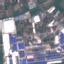

In [12]:
visualize_img()

In [13]:
train_transform = transforms.Compose([
    transforms.ToTensor()
])
test_transform = transforms.Compose([
    transforms.ToTensor()
])

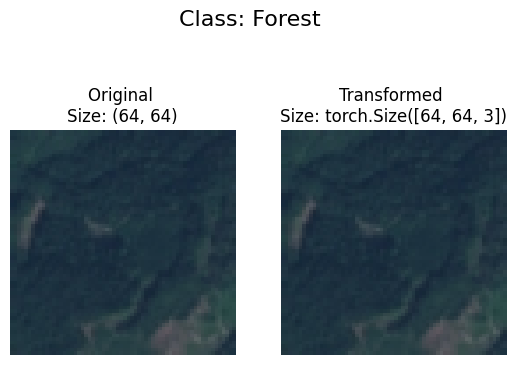

In [14]:
def plot_transformed_img():
  random_category , random_img = _get_random_img(dir_labels,full_data_dir)

  with Image.open(random_img) as f:
      fig, ax = plt.subplots(1, 2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original \nSize: {f.size}")
      ax[0].axis("off")

      # Transform and plot image
      # Note: permute() will change shape of image to suit matplotlib
      # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
      transformed_image = train_transform(f).permute(1, 2, 0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
      ax[1].axis("off")

      fig.suptitle(f"Class: {random_category}", fontsize=16)
plot_transformed_img()


In [15]:
data = datasets.ImageFolder(root=full_data_dir,transform=train_transform,target_transform=None)
data

Dataset ImageFolder
    Number of datapoints: 1050
    Root location: /content/be-mlsys-assignment-dataset/candidate_tiles
    StandardTransform
Transform: Compose(
               ToTensor()
           )

In [16]:
class_names = data.classes
class_names

['AnnualCrop',
 'Forest',
 'Highway',
 'Industrial',
 'Residential',
 'River',
 'SeaLake']

In [17]:
class_dict = data.class_to_idx
class_dict

{'AnnualCrop': 0,
 'Forest': 1,
 'Highway': 2,
 'Industrial': 3,
 'Residential': 4,
 'River': 5,
 'SeaLake': 6}

In [18]:
len(data)

1050

In [19]:
img, label = data[0][0], data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[0.3490, 0.3451, 0.3373,  ..., 0.6510, 0.6471, 0.6588],
         [0.3490, 0.3451, 0.3294,  ..., 0.6510, 0.6471, 0.6549],
         [0.3137, 0.3098, 0.3176,  ..., 0.6549, 0.6549, 0.6588],
         ...,
         [0.5255, 0.5333, 0.5608,  ..., 0.3137, 0.3059, 0.3059],
         [0.5608, 0.5686, 0.6039,  ..., 0.2902, 0.2784, 0.2824],
         [0.5804, 0.5804, 0.5922,  ..., 0.2706, 0.2745, 0.2784]],

        [[0.3882, 0.3922, 0.3804,  ..., 0.5333, 0.5176, 0.5294],
         [0.3922, 0.3882, 0.3843,  ..., 0.5333, 0.5176, 0.5255],
         [0.3725, 0.3686, 0.3765,  ..., 0.5333, 0.5255, 0.5216],
         ...,
         [0.4902, 0.4863, 0.5059,  ..., 0.3529, 0.3490, 0.3569],
         [0.5059, 0.5059, 0.5333,  ..., 0.3490, 0.3490, 0.3529],
         [0.5176, 0.5176, 0.5137,  ..., 0.3451, 0.3490, 0.3529]],

        [[0.3922, 0.3922, 0.3961,  ..., 0.4941, 0.4980, 0.5098],
         [0.4000, 0.3961, 0.3961,  ..., 0.5020, 0.4980, 0.5059],
         [0.3843, 0.3804, 0.3882,  ..., 0.51

In [20]:
total_len = len(data)
train_size = int(total_len * 0.8)
val_size = int(total_len * 0.1)
test_size = total_len - train_size - val_size
train_subset, val_subset, test_subset = torch.utils.data.random_split(range(len(data)), [train_size,val_size,test_size])

In [21]:
len(train_subset),len(test_subset),len(val_subset)

(840, 105, 105)

In [22]:
train_dataset = datasets.ImageFolder(
    full_data_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    full_data_dir,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    full_data_dir,
    transform=test_transform
)

In [23]:
train_dataset = torch.utils.data.Subset(
    train_dataset,
    train_subset.indices
)

val_dataset = torch.utils.data.Subset(
    val_dataset,
    val_subset.indices
)

test_dataset = torch.utils.data.Subset(
    test_dataset,
    test_subset.indices
)

In [24]:
train_dataloader = DataLoader(train_dataset,batch_size=4,num_workers=os.cpu_count(),shuffle=True)
train_dataloader

In [25]:
val_dataloader = DataLoader(val_dataset,batch_size=4,num_workers=os.cpu_count(),shuffle=True)
val_dataloader

In [26]:
test_dataloader = DataLoader(test_dataset,batch_size=4,num_workers=os.cpu_count(),shuffle=True)
test_dataloader

## Model Architecture

Input:         64×64×3

Conv(32, 3×3, stride 1) + ReLU + MaxPool(2)   → 32×32

Conv(64, 3×3, stride 1) + ReLU + MaxPool(2)   → 16×16

Conv(128, 3×3, stride 1) + ReLU + MaxPool(2)  →  8×8

Conv(256, 3×3, stride 1) + ReLU + GAP         →  1×1 (256 channels)

Linear(256 → num_classes)

**Define Model**

In [27]:
class SateliteModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv_block1 = nn.Sequential(

        nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,stride=1,padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2),

        nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )

    self.conv_block2 = nn.Sequential(

        nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,stride=1,padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2),

        nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3,stride=1,padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )

    self.classifier =  nn.Sequential(
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Dropout(0.2),
        nn.Linear(in_features=256,out_features=len(class_names))
    )


  def forward(self, x):
    return self.classifier(self.conv_block2(self.conv_block1(x)))



**Initialize Model**

In [28]:
model = SateliteModel()

**Optimizer and Loss Fn**

In [29]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

**Test on single data**

In [30]:
img_batch, label_batch = next(iter(train_dataloader))

img_single, label_single = img_batch[0].unsqueeze(dim=0).to(device), label_batch[0].to(device)

model.eval()

with torch.inference_mode():
  pred = model(img_single.to(device))



print("Labels:", torch.unique(label_single))
print("Logits:")
print(pred)
print(f"Actual label:\n{label_single}")

loss = loss_fn(pred, label_single.unsqueeze(0))


print("Initial loss:", loss.item())
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")


Labels: tensor([3])
Logits:
tensor([[ 0.0525,  0.0688,  0.0237, -0.0561,  0.0288,  0.0098,  0.0481]])
Actual label:
3
Initial loss: 2.0277628898620605
Output logits:
tensor([[ 0.0525,  0.0688,  0.0237, -0.0561,  0.0288,  0.0098,  0.0481]])

Output prediction probabilities:
tensor([[0.1467, 0.1491, 0.1426, 0.1316, 0.1433, 0.1406, 0.1461]])

Output prediction label:
tensor([1])



**Inspect Model**

In [31]:
try:
    import torchinfo
except:
    !pip install torchinfo
    import torchinfo

from torchinfo import summary
summary(model, input_size=[4, 3, 64, 64]) # do a test pass through of an example input size

Layer (type:depth-idx)                   Output Shape              Param #
SateliteModel                            [4, 7]                    --
├─Sequential: 1-1                        [4, 64, 16, 16]           --
│    └─Conv2d: 2-1                       [4, 32, 64, 64]           896
│    └─BatchNorm2d: 2-2                  [4, 32, 64, 64]           64
│    └─ReLU: 2-3                         [4, 32, 64, 64]           --
│    └─MaxPool2d: 2-4                    [4, 32, 32, 32]           --
│    └─Conv2d: 2-5                       [4, 64, 32, 32]           18,496
│    └─BatchNorm2d: 2-6                  [4, 64, 32, 32]           128
│    └─ReLU: 2-7                         [4, 64, 32, 32]           --
│    └─MaxPool2d: 2-8                    [4, 64, 16, 16]           --
├─Sequential: 1-2                        [4, 256, 4, 4]            --
│    └─Conv2d: 2-9                       [4, 128, 16, 16]          73,856
│    └─BatchNorm2d: 2-10                 [4, 128, 16, 16]          256
│   

**Overfit Test**

In [32]:
def overfit_one_batch(
    model,
    X,
    y,
    loss_fn,
    optimizer
):
    model.train()

    optimizer.zero_grad()

    y_pred = model(X)

    loss = loss_fn(y_pred, y)

    loss.backward()

    optimizer.step()

    y_pred_class = torch.argmax(y_pred, dim=1)

    acc = (y_pred_class == y).float().mean().item()

    return loss.item(), acc

In [33]:
X, y = next(iter(train_dataloader))

X = X.to(device)
y = y.to(device)

for i in range(100):

    loss, acc = overfit_one_batch(
        model=model,
        X=X,
        y=y,
        loss_fn=loss_fn,
        optimizer=optimizer
    )

    if i % 10 == 0:
        print(
            f"Step: {i} | "
            f"Loss: {loss:.4f} | "
            f"Accuracy: {acc:.4f}"
        )

Step: 0 | Loss: 2.3928 | Accuracy: 0.2500
Step: 10 | Loss: 0.0258 | Accuracy: 1.0000
Step: 20 | Loss: 0.0094 | Accuracy: 1.0000
Step: 30 | Loss: 0.0041 | Accuracy: 1.0000
Step: 40 | Loss: 0.0021 | Accuracy: 1.0000
Step: 50 | Loss: 0.0035 | Accuracy: 1.0000
Step: 60 | Loss: 0.0015 | Accuracy: 1.0000
Step: 70 | Loss: 0.0015 | Accuracy: 1.0000
Step: 80 | Loss: 0.0012 | Accuracy: 1.0000
Step: 90 | Loss: 0.0012 | Accuracy: 1.0000


## Training

In [34]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):

  train_loss, train_acc = 0, 0

  for X,y in dataloader:
      X, y = X.to(device),y.to(device)
      y_pred = model(X)

      loss = loss_fn(y_pred, y)
      train_loss += loss.item()

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      y_pred_class = torch.argmax(y_pred, dim=1)
      train_acc += (y_pred_class == y).float().mean().item()

  train_acc = train_acc / len(dataloader)
  train_loss = train_loss / len(dataloader)
  return train_acc, train_loss

In [35]:
def val_step(model:torch.nn.Module, dataloader: torch.utils.data.DataLoader,loss_fn:torch.nn.Module,optimizer:torch.optim.Optimizer):
  test_acc, test_loss = 0, 0

  for X,y in dataloader:
    X,y = X.to(device), y.to(device)
    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    test_loss += loss.item()

    y_pred_class = torch.argmax(y_pred, dim=1)
    test_acc += (y_pred_class == y).float().mean().item()

  test_acc = test_acc / len(dataloader)
  test_loss = test_loss / len(dataloader)
  return test_acc, test_loss

In [36]:
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          val_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    best_val_loss = float("inf")
    patience = 3
    counter = 0
    best_val_acc = 0

    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in tqdm(range(epochs)):
        train_acc, train_loss = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_acc, test_loss = val_step(model=model,
            dataloader=val_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer
          )

        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)


        if test_loss < best_val_loss:

            best_val_loss = test_loss
            best_val_acc = test_acc
            counter = 0

            torch.save(
                model.state_dict(),
                "model.pth"
            )

        else:

            counter += 1

            if counter >= patience:
                print(f"Early stopping triggered. and best val loss: {best_val_loss} and best acc: {best_val_acc} ")
                break

    return results

In [37]:
NUM_EPOCHS = 10

model = SateliteModel()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [39]:
start_timer = timer()

model_results = train(model=model,
                        train_dataloader=train_dataloader,
                        val_dataloader=val_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

end_time = timer()
print(f"Total training time: {end_time-start_timer:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.4840 | train_acc: 0.4310 | test_loss: 1.4589 | test_acc: 0.4352
Epoch: 2 | train_loss: 1.2134 | train_acc: 0.5310 | test_loss: 1.1519 | test_acc: 0.5370
Epoch: 3 | train_loss: 1.1296 | train_acc: 0.5667 | test_loss: 0.9991 | test_acc: 0.6111
Epoch: 4 | train_loss: 1.0600 | train_acc: 0.5929 | test_loss: 0.9486 | test_acc: 0.6759
Epoch: 5 | train_loss: 0.9846 | train_acc: 0.6012 | test_loss: 1.0335 | test_acc: 0.6389
Epoch: 6 | train_loss: 0.9292 | train_acc: 0.6548 | test_loss: 1.1340 | test_acc: 0.5926
Epoch: 7 | train_loss: 0.7887 | train_acc: 0.6905 | test_loss: 0.7793 | test_acc: 0.6667
Epoch: 8 | train_loss: 0.8192 | train_acc: 0.6750 | test_loss: 0.8485 | test_acc: 0.6944
Epoch: 9 | train_loss: 0.7003 | train_acc: 0.7333 | test_loss: 0.9813 | test_acc: 0.6667
Epoch: 10 | train_loss: 0.7572 | train_acc: 0.7179 | test_loss: 0.8738 | test_acc: 0.6481
Early stopping triggered. and best val loss: 0.7793495842704067 and best acc: 0.6666666666666666 
Total train

## Test/Evaluation

In [40]:
len(test_dataloader)

27

In [42]:
def test_data(model: torch.nn.Module, test_dataloader: torch.utils.data.DataLoader):
  test_acc = 0

  for X, y in test_dataloader:

    pred = model(X)

    pred_classes = torch.argmax(pred, dim=1)
    test_acc += (y == pred_classes).float().mean().item()

  test_acc /= len(test_dataloader)
  print(f"Test Accuracy is: {test_acc}")

test_data(model=model,test_dataloader=test_dataloader)


Test Accuracy is: 0.6574074074074074


## Inference

In [43]:
satelite_model = SateliteModel()
satelite_model

SateliteModel(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(256, eps=1e-05, momentum=0.1, af

In [45]:
torchinfo.summary(satelite_model)

Layer (type:depth-idx)                   Param #
SateliteModel                            --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       896
│    └─BatchNorm2d: 2-2                  64
│    └─ReLU: 2-3                         --
│    └─MaxPool2d: 2-4                    --
│    └─Conv2d: 2-5                       18,496
│    └─BatchNorm2d: 2-6                  128
│    └─ReLU: 2-7                         --
│    └─MaxPool2d: 2-8                    --
├─Sequential: 1-2                        --
│    └─Conv2d: 2-9                       73,856
│    └─BatchNorm2d: 2-10                 256
│    └─ReLU: 2-11                        --
│    └─MaxPool2d: 2-12                   --
│    └─Conv2d: 2-13                      295,168
│    └─BatchNorm2d: 2-14                 512
│    └─ReLU: 2-15                        --
│    └─MaxPool2d: 2-16                   --
├─Sequential: 1-3                        --
│    └─AdaptiveAvgPool2d: 2-17           --
│    └─Fla

In [47]:
model_weights_path = "/content/model.pth"

In [52]:
model_weights = torch.load(f=model_weights_path)
model_weights

OrderedDict([('conv_block1.0.weight',
              tensor([[[[-1.6934e-01,  2.0133e-02,  6.2987e-02],
                        [ 5.6590e-02, -2.0831e-02,  2.0546e-01],
                        [-1.9565e-01, -1.9657e-01,  1.4763e-01]],
              
                       [[-1.7323e-01,  2.4857e-02,  2.8483e-02],
                        [ 1.5155e-01, -1.5368e-01,  1.6701e-01],
                        [ 1.5862e-01, -9.2721e-02,  6.3150e-02]],
              
                       [[ 1.1702e-01,  1.6606e-01, -3.8170e-02],
                        [-5.1568e-03,  8.2893e-02,  2.5451e-02],
                        [-7.7908e-02, -1.5633e-01, -3.9089e-02]]],
              
              
                      [[[-6.9345e-02, -8.4516e-02, -7.7206e-02],
                        [-1.8030e-01, -1.7797e-01, -3.1283e-02],
                        [-5.2185e-02, -1.8043e-02,  3.0287e-02]],
              
                       [[ 2.0559e-01,  1.2911e-01, -1.4118e-01],
                        [ 1.5389e-02,

In [53]:
satelite_model.load_state_dict(model_weights)

<All keys matched successfully>

In [62]:
X, y = next(iter(train_dataloader))
X, y = X[0].unsqueeze(0), y[0]

In [63]:
y

tensor(1)

In [64]:
pred = satelite_model(X)
pred

tensor([[-1.2477, -2.0637, -0.3278, -4.9526, -3.0976, -0.7571, -1.6721]],
       grad_fn=<AddmmBackward0>)

In [65]:
torch.argmax(pred,dim=1)

tensor([2])

In [66]:
torch.softmax(pred,dim=1)

tensor([[0.1557, 0.0689, 0.3908, 0.0038, 0.0245, 0.2544, 0.1019]],
       grad_fn=<SoftmaxBackward0>)